In [3]:
#1
# Read integers from input.txt and insert them into the tree
# Node of Red-Black Tree

import time
import random
import matplotlib.pyplot as plt
RED = "RED"
BLACK = "BLACK"
class Node:
    def __init__(self, key):
        self.key = key
        self.color = RED
        self.left = None
        self.right = None
        self.parent = None

class RedBlackTree:
    def __init__(self):
        self.NIL = Node(None)
        self.NIL.color = BLACK
        self.root = self.NIL
        
# Insert a key into the Red-Black Tree
    def insert(self, key):
        new_node = Node(key)
        new_node.left = self.NIL
        new_node.right = self.NIL
        parent = self.NIL
        current = self.root

# Find the correct position
        while current != self.NIL:
            parent = current
            if key < current.key:
                current = current.left
            elif key > current.key:
                current = current.right
            else:
                return

        # Set parent
        new_node.parent = parent

        # If tree is empty
        if parent == self.NIL:
            self.root = new_node

        # Insert to left
        elif key < parent.key:
            parent.left = new_node

        # Insert to right
        else:
            parent.right = new_node

        # New node is RED
        new_node.color = RED

# MAIN PROGRAM
tree = RedBlackTree()
# Read integers from input.txt
with open("input.txt", "r") as file:
    numbers = list(map(int, file.read().split()))

# Insert each number into the Red-Black Tree
for number in numbers:
    tree.insert(number)
    print("Inserted:", number)
print("\nAll elements inserted successfully.")

Inserted: 50
Inserted: 30
Inserted: 70
Inserted: 20
Inserted: 40
Inserted: 60
Inserted: 80
Inserted: 10
Inserted: 25
Inserted: 35
Inserted: 45
Inserted: 55
Inserted: 65
Inserted: 75
Inserted: 90

All elements inserted successfully.


In [7]:
#2
# Red-Black Tree Insertion
# Includes:
# 1. Recolouring
# 2. LL Rotation
# 3. RR Rotation
# 4. LR Rotation
# 5. RL Rotation

RED = "RED"
BLACK = "BLACK"
# NODE
class Node:
    def __init__(self, key):
        self.key = key
        self.color = RED
        self.left = None
        self.right = None
        self.parent = None


# RED-BLACK TREE
class RedBlackTree:
    def __init__(self):
        self.NIL = Node(None)
        self.NIL.color = BLACK
        self.root = self.NIL
        
# LEFT ROTATION
    def left_rotate(self, x):
        y = x.right
        x.right = y.left
        if y.left != self.NIL:
            y.left.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.left:
            x.parent.left = y
        else:
            x.parent.right = y
        y.left = x
        x.parent = y   
        
# RIGHT ROTATION
    def right_rotate(self, x):
        y = x.left
        x.left = y.right
        if y.right != self.NIL:
            y.right.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.right:
            x.parent.right = y
        else:
            x.parent.left = y
        y.right = x
        x.parent = y
        
# INSERT
    def insert(self, key):
        new_node = Node(key)
        new_node.left = self.NIL
        new_node.right = self.NIL
        parent = self.NIL
        current = self.root
        
# Find the correct position
        while current != self.NIL:
            parent = current
            if key < current.key:
                current = current.left
            elif key > current.key:
                current = current.right
            else:
                return

# Set parent
        new_node.parent = parent       
# Tree is empty
        if parent == self.NIL:
            self.root = new_node

        # Insert on left
        elif key < parent.key:
            parent.left = new_node
        # Insert on right
        else:
            parent.right = new_node
        # New node is RED
        new_node.color = RED

        # Fix Red-Black Tree
        self.insert_fix(new_node)

# INSERT FIX
    def insert_fix(self, z):
        while z.parent.color == RED:
            # CASE 1: Parent is LEFT child
            if z.parent == z.parent.parent.left:
                uncle = z.parent.parent.right
# RECOLOURING

                if uncle.color == RED:
                    z.parent.color = BLACK
                    uncle.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
 # LR CASE
        

                    if z == z.parent.right:
                        z = z.parent
                        self.left_rotate(z)          
# LL CASE
                
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.right_rotate(z.parent.parent)

# CASE 2: Parent is RIGHT child
            else:
                uncle = z.parent.parent.left
                # RECOLOURING
                if uncle.color == RED:
                    z.parent.color = BLACK
                    uncle.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
# RL CASE
                    
                    if z == z.parent.left:
                        z = z.parent
                        self.right_rotate(z)
# RR CASE
                
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.left_rotate(z.parent.parent)


# Root must always be BLACK
        self.root.color = BLACK

# INORDER TRAVERSAL

    def inorder(self, node=None):
        if node is None:
            node = self.root
        if node != self.NIL:            
            self.inorder(node.left)
            print(node.key, "(", node.color, ")", end=" ")
            self.inorder(node.right)
# MAIN PROGRAM
tree = RedBlackTree()
# Read numbers from input.txt
with open("input.txt", "r") as file:
    numbers = list(map(int, file.read().split()))
    
# Insert numbers one by one
for number in numbers:
    tree.insert(number)
# Display tree
print("Red-Black Tree after insertion:")
tree.inorder()

Red-Black Tree after insertion:
10 ( RED ) 20 ( BLACK ) 25 ( RED ) 30 ( RED ) 35 ( RED ) 40 ( BLACK ) 45 ( RED ) 50 ( BLACK ) 55 ( RED ) 60 ( BLACK ) 65 ( RED ) 70 ( RED ) 75 ( RED ) 80 ( BLACK ) 90 ( RED ) 

In [14]:
#3 DELETE(KEY)
RED = "RED"
BLACK = "BLACK"

# NODE
class Node:
    def __init__(self, key):
        self.key = key
        self.color = RED
        self.left = None
        self.right = None
        self.parent = None
# RED-BLACK TREE
class RedBlackTree:
    def __init__(self):
        self.NIL = Node(None)
        self.NIL.color = BLACK
        self.NIL.left = self.NIL
        self.NIL.right = self.NIL
        self.NIL.parent = self.NIL
        self.root = self.NIL

    # LEFT ROTATION
    def left_rotate(self, x):
        y = x.right
        x.right = y.left
        if y.left != self.NIL:
            y.left.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.left:
            x.parent.left = y
        else:

            x.parent.right = y
        y.left = x
        x.parent = y
    
    # RIGHT ROTATION
    def right_rotate(self, x):
        y = x.left
        x.left = y.right
        if y.right != self.NIL:
            y.right.parent = x
        y.parent = x.parent
        if x.parent == self.NIL:
            self.root = y
        elif x == x.parent.right:
            x.parent.right = y
        else:
           x.parent.left = y
        y.right = x
        x.parent = y
# INSERT
    def insert(self, key):
        new_node = Node(key)
        new_node.left = self.NIL
        new_node.right = self.NIL
        parent = self.NIL
        current = self.root
        while current != self.NIL:
            parent = current
            if key < current.key:
                current = current.left
            elif key > current.key:
                current = current.right
            else:
                return
        new_node.parent = parent
        if parent == self.NIL:
            self.root = new_node
        elif key < parent.key:
            parent.left = new_node
        else:
            parent.right = new_node
        new_node.color = RED
        self.insert_fix(new_node)
    
    # INSERT FIX
    def insert_fix(self, z):
        while z.parent.color == RED:
            if z.parent == z.parent.parent.left:
                uncle = z.parent.parent.right
                if uncle.color == RED:
                    z.parent.color = BLACK
                    uncle.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z == z.parent.right:
                        z = z.parent
                        self.left_rotate(z)
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.right_rotate(z.parent.parent)
            else:
                uncle = z.parent.parent.left
                if uncle.color == RED:
                    z.parent.color = BLACK
                    uncle.color = BLACK
                    z.parent.parent.color = RED
                    z = z.parent.parent
                else:
                    if z == z.parent.left:
                        z = z.parent
                        self.right_rotate(z)
                    z.parent.color = BLACK
                    z.parent.parent.color = RED
                    self.left_rotate(z.parent.parent)
        self.root.color = BLACK
    # SEARCH
    def search(self, key):
        current = self.root
        while current != self.NIL:
            if key == current.key:
                return current
            elif key < current.key:
                current = current.left
            else:
                current = current.right
        return None
    # MINIMUM
    def minimum(self, node):
        while node.left != self.NIL:
            node = node.left
        return node
    # TRANSPLANT
    def transplant(self, u, v):
        if u.parent == self.NIL:
            self.root = v
        elif u == u.parent.left:
            u.parent.left = v
        else:
            u.parent.right = v
        v.parent = u.parent
    # DELETE
    def delete(self, key):
        z = self.search(key)
        if z is None:
            print("Key not found:", key)
            return
        y = z
        original_color = y.color
        # CASE 1
        # No left child
        if z.left == self.NIL:
            x = z.right
            self.transplant(z, z.right)

        # CASE 2
        # No right child
        elif z.right == self.NIL:
            x = z.left
            self.transplant(z, z.left)

        # CASE 3
        # Two children
        else:
            y = self.minimum(z.right)
            original_color = y.color
            x = y.right
            if y.parent == z:
                x.parent = y
            else:
                self.transplant(y, y.right)
                y.right = z.right
                y.right.parent = y
            self.transplant(z, y)
            y.left = z.left
            y.left.parent = y
            y.color = z.color
        # If deleted node was BLACK,
        # fix the Red-Black properties
        if original_color == BLACK:
            self.delete_fix(x)
            
    # DELETE FIX
    def delete_fix(self, x):
        while x != self.root and x.color == BLACK:
            # x is LEFT child
            if x == x.parent.left:
                sibling = x.parent.right
                # Case 1
                if sibling.color == RED:
                    sibling.color = BLACK
                    x.parent.color = RED
                    self.left_rotate(x.parent)
                    sibling = x.parent.right
                # Case 2
                if (sibling.left.color == BLACK and
                        sibling.right.color == BLACK):
                    sibling.color = RED
                    x = x.parent
                else:
                    # Case 3
                    if sibling.right.color == BLACK:
                        sibling.left.color = BLACK
                        sibling.color = RED
                        self.right_rotate(sibling)
                        sibling = x.parent.right
                    # Case 4
                    sibling.color = x.parent.color
                    x.parent.color = BLACK
                    sibling.right.color = BLACK
                    self.left_rotate(x.parent)
                    x = self.root
            # x is RIGHT child 
            else:
                sibling = x.parent.left
                # Case 1
                if sibling.color == RED:
                    sibling.color = BLACK
                    x.parent.color = RED
                    self.right_rotate(x.parent)
                    sibling = x.parent.left
                # Case 2
                if (sibling.right.color == BLACK and
                        sibling.left.color == BLACK):
                    sibling.color = RED
                    x = x.parent
                else:

                    # Case 3
                    if sibling.left.color == BLACK:
                        sibling.right.color = BLACK
                        sibling.color = RED
                        self.left_rotate(sibling)
                        sibling = x.parent.left

                    # Case 4
                    sibling.color = x.parent.color
                    x.parent.color = BLACK
                    sibling.left.color = BLACK
                    self.right_rotate(x.parent)
                    x = self.root
                    x.color = BLACK
# INORDER
    def inorder(self, node=None):
        if node is None:
            node = self.root
        if node != self.NIL:
            self.inorder(node.left)
            print(node.key, "(", node.color, ")", end=" ")
            self.inorder(node.right)
# MAIN
tree = RedBlackTree()
# Insert elements
numbers = [50, 30, 70, 20, 40, 60, 80, 10, 25]
for number in numbers:
    tree.insert(number)
print("Tree before deletion:")
tree.inorder()
# Delete a specified element
key = 30
print("\n\nDeleting:", key)
tree.delete(key)
print("\nTree after deletion:")
tree.inorder()

Tree before deletion:
10 ( RED ) 20 ( BLACK ) 25 ( RED ) 30 ( RED ) 40 ( BLACK ) 50 ( BLACK ) 60 ( RED ) 70 ( BLACK ) 80 ( RED ) 

Deleting: 30

Tree after deletion:
10 ( BLACK ) 20 ( RED ) 25 ( RED ) 40 ( BLACK ) 50 ( BLACK ) 60 ( RED ) 70 ( BLACK ) 80 ( RED ) 

In [27]:
#4
# IN-ORDER TRAVERSAL
def inorder(self, node=None):
    if node is None:
        node = self.root
    if node != self.NIL:
        # Visit left subtree
        self.inorder(node.left)
        # Visit root
        print(node.key, "(", node.color, ")", end=" ")
        # Visit right subtree
        self.inorder(node.right)

# MAIN PROGRAM
tree = RedBlackTree()
# Read numbers from input.txt
with open("input.txt", "r") as file:
    numbers = list(map(int, file.read().split()))

# INSERTION
for number in numbers:
    tree.insert(number)
# Display after insertion
print("In-order traversal after insertion:")
tree.inorder()
# DELETION
key = int(input("\n\nEnter the element to delete: "))
tree.delete(key)
# Display after deletion
print("\nIn-order traversal after deletion:")
tree.inorder()


In-order traversal after insertion:
10 ( RED ) 20 ( BLACK ) 25 ( RED ) 30 ( RED ) 35 ( RED ) 40 ( BLACK ) 45 ( RED ) 50 ( BLACK ) 55 ( RED ) 60 ( BLACK ) 65 ( RED ) 70 ( RED ) 75 ( RED ) 80 ( BLACK ) 90 ( RED ) 



Enter the element to delete:  30



In-order traversal after deletion:
10 ( RED ) 20 ( BLACK ) 25 ( RED ) 35 ( RED ) 40 ( BLACK ) 45 ( RED ) 50 ( BLACK ) 55 ( RED ) 60 ( BLACK ) 65 ( RED ) 70 ( RED ) 75 ( RED ) 80 ( BLACK ) 90 ( RED ) 

Testing for n = 100
Testing for n = 500
Testing for n = 1000
Testing for n = 5000
Testing for n = 10000
Testing for n = 50000

 RESULTS

Nodes: 100
Height: 8
Insertion Time: 0.00021309999283403158
Deletion Time: 0.00012949993833899498
Search Time: 5.779997445642948e-05

Nodes: 500
Height: 11
Insertion Time: 0.0008382999803870916
Deletion Time: 0.00016939989291131496
Search Time: 8.180004078894854e-05

Nodes: 1000
Height: 12
Insertion Time: 0.002018099999986589
Deletion Time: 0.0001996000064536929
Search Time: 8.740008343011141e-05

Nodes: 5000
Height: 15
Insertion Time: 0.012424999964423478
Deletion Time: 0.00021279999054968357
Search Time: 0.00011040002573281527

Nodes: 10000
Height: 16
Insertion Time: 0.040999700082466006
Deletion Time: 0.0002631999086588621
Search Time: 0.0001705000177025795

Nodes: 50000
Height: 19
Insertion Time: 0.16761789994779974
Deletion Time: 0.00023380003403872252
Search Time: 0.00020530004985630512


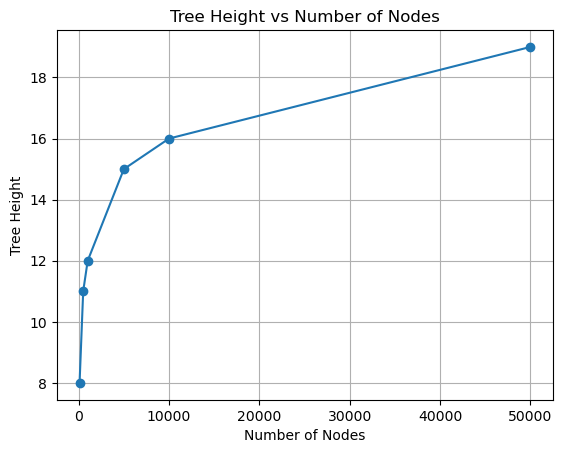

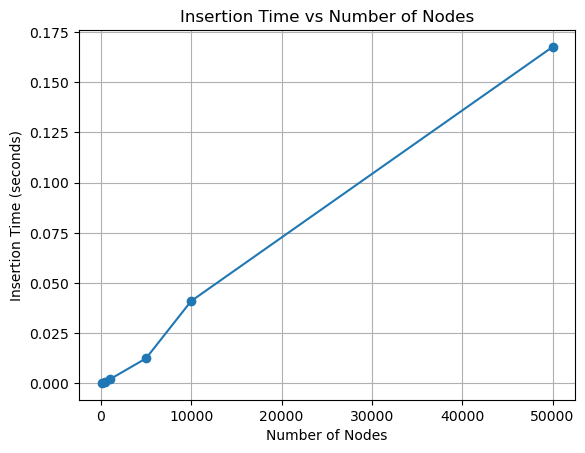

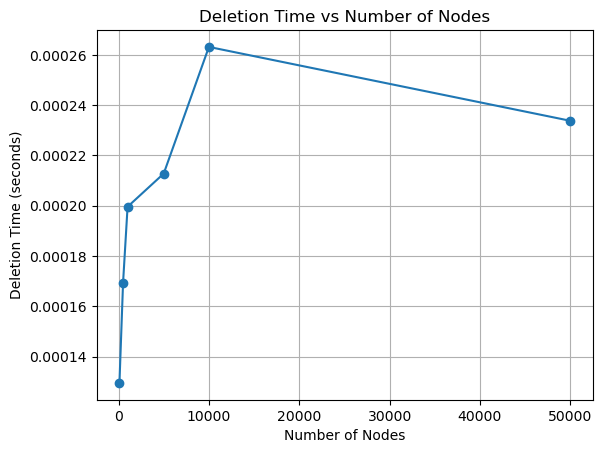

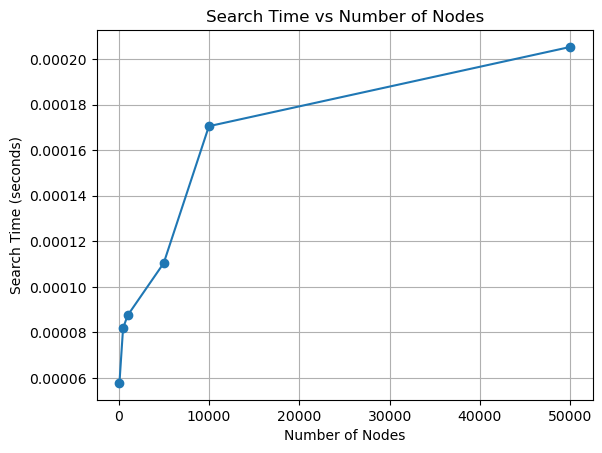

In [29]:
#6
import random
import time
import matplotlib.pyplot as plt
# HEIGHT FUNCTION
def get_height(tree, node):
    if node == tree.NIL:
        return 0
    left_height = get_height(tree, node.left)
    right_height = get_height(tree, node.right)

    return 1 + max(left_height, right_height)
# NUMBER OF NODES
sizes = [100, 500, 1000, 5000, 10000, 50000]
# Lists for storing results
heights = []
insertion_times = []
deletion_times = []
search_times = []
# PERFORMANCE TEST
for n in sizes:
    print("Testing for n =", n)
    # Generate random data
    data = list(range(1, n + 1))
    random.shuffle(data)
    # Create Red-Black Tree
    tree = RedBlackTree()
    
#INSERTION TIME 
    start = time.perf_counter()
    for value in data:
        tree.insert(value)
    end = time.perf_counter()
    insertion_time = end - start
    insertion_times.append(insertion_time)

# TREE HEIGHT 
    height = get_height(tree, tree.root)
    heights.append(height)


# SEARCH TIME
    search_values = random.sample(data, min(100, n))
    start = time.perf_counter()
    for value in search_values:
        tree.search(value)
    end = time.perf_counter()
    search_time = end - start
    search_times.append(search_time)
# DELETION TIME 
    # Delete 100 elements
    delete_values = data[:min(100, n)]
    start = time.perf_counter()
    for value in delete_values:
        tree.delete(value)
    end = time.perf_counter()
    deletion_time = end - start
    deletion_times.append(deletion_time)

# PRINT RESULTS
print("\n RESULTS")
for i in range(len(sizes)):
    print("\nNodes:", sizes[i])
    print("Height:", heights[i])
    print("Insertion Time:", insertion_times[i])
    print("Deletion Time:", deletion_times[i])
    print("Search Time:", search_times[i])

# GRAPH 1: HEIGHT VS NUMBER OF NODES
plt.figure()
plt.plot(sizes, heights, marker='o')
plt.xlabel("Number of Nodes")
plt.ylabel("Tree Height")
plt.title("Tree Height vs Number of Nodes")
plt.grid()
plt.show()

# GRAPH 2: INSERTION TIME VS NUMBER OF NODES
plt.figure()
plt.plot(sizes, insertion_times, marker='o')
plt.xlabel("Number of Nodes")
plt.ylabel("Insertion Time (seconds)")
plt.title("Insertion Time vs Number of Nodes")
plt.grid()
plt.show()


# GRAPH 3: DELETION TIME VS NUMBER OF NODES
plt.figure()
plt.plot(sizes, deletion_times, marker='o')
plt.xlabel("Number of Nodes")
plt.ylabel("Deletion Time (seconds)")
plt.title("Deletion Time vs Number of Nodes")
plt.grid()
plt.show()

# GRAPH 4: SEARCH TIME VS NUMBER OF NODES
plt.figure()
plt.plot(sizes, search_times, marker='o')
plt.xlabel("Number of Nodes")
plt.ylabel("Search Time (seconds)")
plt.title("Search Time vs Number of Nodes")
plt.grid()
plt.show()

Testing n = 100
Testing n = 500
Testing n = 1000
Testing n = 5000
Testing n = 10000
Testing n = 50000

 COMPARISON 

Number of Nodes: 100
BST Height: 14
RBT Height: 8
BST Search Time: 7.6299998909235e-05
RBT Search Time: 7.830001413822174e-05

Number of Nodes: 500
BST Height: 19
RBT Height: 11
BST Search Time: 0.00010519998613744974
RBT Search Time: 0.00010429997928440571

Number of Nodes: 1000
BST Height: 25
RBT Height: 12
BST Search Time: 0.0001805999781936407
RBT Search Time: 0.0001650999765843153

Number of Nodes: 5000
BST Height: 29
RBT Height: 15
BST Search Time: 0.00027570000384002924
RBT Search Time: 0.0002595999976620078

Number of Nodes: 10000
BST Height: 32
RBT Height: 16
BST Search Time: 0.00037999998312443495
RBT Search Time: 0.00035039999056607485

Number of Nodes: 50000
BST Height: 38
RBT Height: 19
BST Search Time: 0.0004021000349894166
RBT Search Time: 0.00035259989090263844


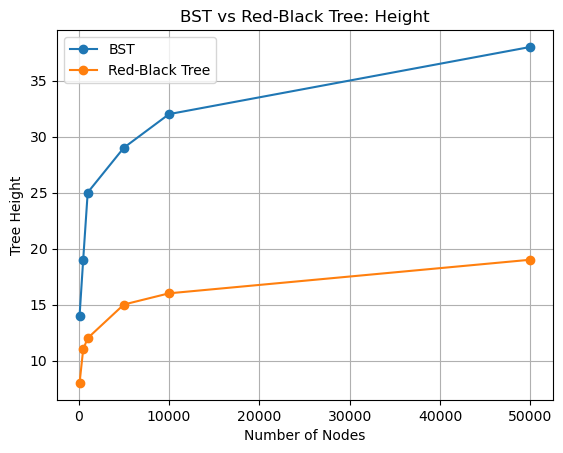

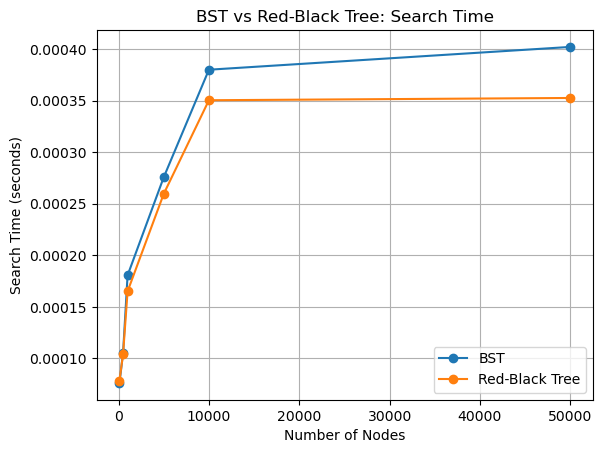

In [30]:
#7
import random
import time
import matplotlib.pyplot as plt

# ORDINARY BST
class BSTNode:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None
class BST:
    def __init__(self):
        self.root = None
    # Insert
    def insert(self, key):
        new_node = BSTNode(key)
        if self.root is None:
            self.root = new_node
            return
        current = self.root
        while True:
            if key < current.key:
                if current.left is None:
                    current.left = new_node
                    return
                current = current.left
            elif key > current.key:
                if current.right is None:
                    current.right = new_node
                    return
                current = current.right
            else:
                return

    # Search
    def search(self, key):
        current = self.root
        while current is not None:
            if key == current.key:
                return current
            elif key < current.key:
                current = current.left
            else:
                current = current.right
        return None

    # Height
    def height(self, node=None):
        if node is None:
            node = self.root
        if node is None:
            return 0
        # Iterative height calculation
        queue = [node]
        height = 0
        while queue:
            height += 1
            next_level = []
            for current in queue:
                if current.left is not None:
                    next_level.append(current.left)

                if current.right is not None:
                    next_level.append(current.right)
            queue = next_level
        return height
        
# RED-BLACK TREE
# Use your Red-Black Tree class from Tasks 1-5 here.
#
# It should contain:
#     insert(key)
#     search(key)
#     root
#     NIL
# Height function for Red-Black Tree
def rbt_height(tree, node=None):
    if node is None:
        node = tree.root
    if node == tree.NIL:
        return 0
    left_height = rbt_height(tree, node.left)
    right_height = rbt_height(tree, node.right)
    return 1 + max(left_height, right_height)
    
# EXPERIMENT
sizes = [100, 500, 1000, 5000, 10000, 50000]
bst_heights = []
rbt_heights = []
bst_search_times = []
rbt_search_times = []
for n in sizes:
    print("Testing n =", n)
    # Generate random data
    data = list(range(1, n + 1))
    random.shuffle(data)
    # CREATE BST
    bst = BST()
    for value in data:
        bst.insert(value)
        
    # CREATE RED-BLACK TREE
    rbt = RedBlackTree()
    for value in data:
        rbt.insert(value)
    
    # HEIGHT
    bst_height = bst.height()
    rbt_height_value = rbt_height(rbt)

    bst_heights.append(bst_height)
    rbt_heights.append(rbt_height_value)

    # SEARCH TIME - BST
    search_values = random.sample(data, min(100, n))
    start = time.perf_counter()
    for value in search_values:
        bst.search(value)
    end = time.perf_counter()
    bst_search_times.append(end - start)

  # SEARCH TIME - RED-BLACK TREE
    start = time.perf_counter()
    for value in search_values:
        rbt.search(value)
    end = time.perf_counter()
    rbt_search_times.append(end - start)
# DISPLAY RESULTS

print("\n COMPARISON ")

for i in range(len(sizes)):
    print("\nNumber of Nodes:", sizes[i])
    print("BST Height:", bst_heights[i])
    print("RBT Height:", rbt_heights[i])
    print("BST Search Time:", bst_search_times[i])
    print("RBT Search Time:", rbt_search_times[i])

# GRAPH 1: HEIGHT COMPARISON
plt.figure()
plt.plot(sizes, bst_heights, marker='o', label="BST")
plt.plot(sizes, rbt_heights, marker='o', label="Red-Black Tree")
plt.xlabel("Number of Nodes")
plt.ylabel("Tree Height")
plt.title("BST vs Red-Black Tree: Height")
plt.legend()
plt.grid()
plt.show()

# GRAPH 2: SEARCH TIME COMPARISON
plt.figure()
plt.plot(sizes, bst_search_times, marker='o', label="BST")
plt.plot(sizes, rbt_search_times, marker='o', label="Red-Black Tree")
plt.xlabel("Number of Nodes")
plt.ylabel("Search Time (seconds)")
plt.title("BST vs Red-Black Tree: Search Time")
plt.legend()
plt.grid()
plt.show()



Random DATA
 
Key not found: 13
Key not found: 26
Key not found: 11
Key not found: 12
Key not found: 25
Key not found: 24

Nodes: 100
Height: 8
Insertion Time: 0.00017060001846402884
Deletion Time: 0.00023689994122833014
Search Time: 5.48000680282712e-05

Nodes: 500
Height: 11
Insertion Time: 0.0008196999551728368
Deletion Time: 0.00019429996609687805
Search Time: 8.150003850460052e-05

Nodes: 1000
Height: 12
Insertion Time: 0.0021881000138819218
Deletion Time: 0.00018550001550465822
Search Time: 8.509994950145483e-05

Nodes: 5000
Height: 15
Insertion Time: 0.01281740004196763
Deletion Time: 0.0002845000708475709
Search Time: 0.0001607000594958663

Nodes: 10000
Height: 17
Insertion Time: 0.032616900047287345
Deletion Time: 0.0004373999545350671
Search Time: 0.0002592999953776598

Nodes: 50000
Height: 19
Insertion Time: 0.20323790004476905
Deletion Time: 0.0004591000033542514
Search Time: 0.00033140007872134447


Sorted DATA
 

Nodes: 100
Height: 11
Insertion Time: 0.00021249998826533

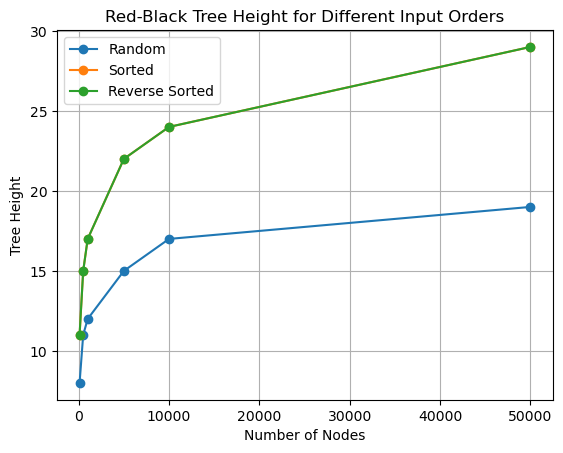

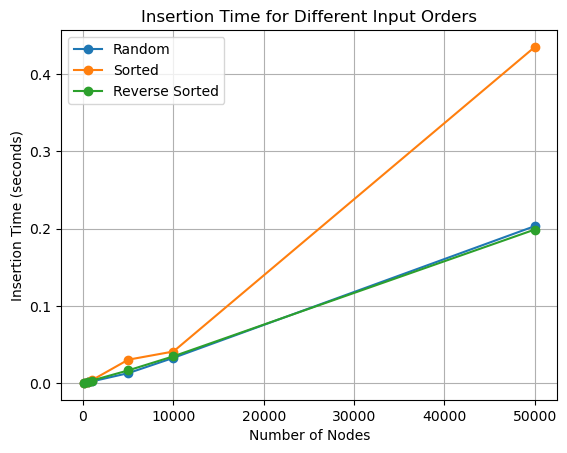

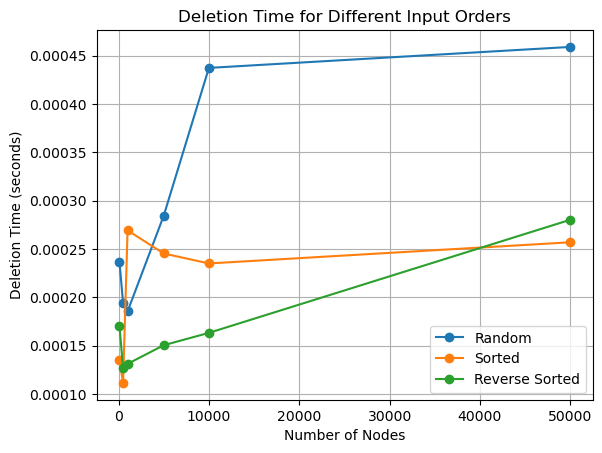

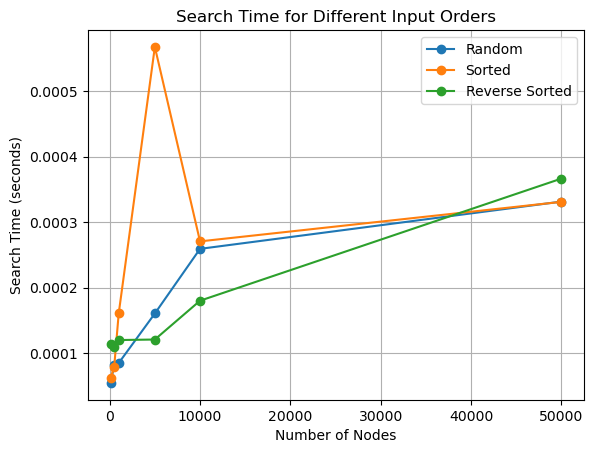

In [31]:
#8
import random
import time
import matplotlib.pyplot as plt
# HEIGHT FUNCTION
def get_height(tree, node=None):
    if node is None:
        node = tree.root
    if node == tree.NIL:
        return 0
    left_height = get_height(tree, node.left)
    right_height = get_height(tree, node.right)
    return 1 + max(left_height, right_height)
# TEST SIZES
sizes = [100, 500, 1000, 5000, 10000, 50000]
cases = ["Random", "Sorted", "Reverse Sorted"]

# Store results
results = {
    "Random": [],
    "Sorted": [],
    "Reverse Sorted": []
}
# EXPERIMENT
for case in cases:
    print("\n")
    print(case, "DATA")
    print(" ")
    for n in sizes:
        # CREATE INPUT DATA
        if case == "Random":
            data = list(range(1, n + 1))
            random.shuffle(data)
        elif case == "Sorted":
            data = list(range(1, n + 1))
        else:
            data = list(range(n, 0, -1))
-
        # CREATE RED-BLACK TREE
        tree = RedBlackTree()

        # INSERTION TIME
        start = time.perf_counter()
        for value in data:
            tree.insert(value)
        end = time.perf_counter()
        insertion_time = end - start
        # HEIGHT
        height = get_height(tree)

        # SEARCH TIME
        search_values = random.sample(data, min(100, n))
        start = time.perf_counter()
        for value in search_values:
            tree.search(value)
        end = time.perf_counter()
        search_time = end - start

        # DELETION TIME
        delete_values = data[:min(100, n)]
        start = time.perf_counter()
        for value in delete_values:
            tree.delete(value)
        end = time.perf_counter()
        deletion_time = end - start

        # STORE RESULTS
        results[case].append(
            (height, insertion_time, deletion_time, search_time)
        )
        # PRINT RESULTS
        print("\nNodes:", n)
        print("Height:", height)
        print("Insertion Time:", insertion_time)
        print("Deletion Time:", deletion_time)
        print("Search Time:", search_time)

# GRAPH 1: HEIGHT
plt.figure()
for case in cases:
    heights = []
    for result in results[case]:
        heights.append(result[0])
    plt.plot(sizes, heights, marker='o', label=case)
plt.xlabel("Number of Nodes")
plt.ylabel("Tree Height")
plt.title("Red-Black Tree Height for Different Input Orders")

plt.legend()
plt.grid()
plt.show()


# =========================================================
# GRAPH 2: INSERTION TIME
# =========================================================

plt.figure()

for case in cases:

    times = []

    for result in results[case]:
        times.append(result[1])

    plt.plot(sizes, times, marker='o', label=case)

plt.xlabel("Number of Nodes")
plt.ylabel("Insertion Time (seconds)")
plt.title("Insertion Time for Different Input Orders")

plt.legend()
plt.grid()
plt.show()


# =========================================================
# GRAPH 3: DELETION TIME
# =========================================================

plt.figure()

for case in cases:

    times = []

    for result in results[case]:
        times.append(result[2])

    plt.plot(sizes, times, marker='o', label=case)

plt.xlabel("Number of Nodes")
plt.ylabel("Deletion Time (seconds)")
plt.title("Deletion Time for Different Input Orders")

plt.legend()
plt.grid()
plt.show()


# =========================================================
# GRAPH 4: SEARCH TIME
# =========================================================

plt.figure()

for case in cases:

    times = []

    for result in results[case]:
        times.append(result[3])

    plt.plot(sizes, times, marker='o', label=case)

plt.xlabel("Number of Nodes")
plt.ylabel("Search Time (seconds)")
plt.title("Search Time for Different Input Orders")

plt.legend()
plt.grid()
plt.show()